#Understanding the Impact of Kernel Choice on Support Vector Machine Performance


##GITHUB-https://github.com/Ssairamreddy06/MachineLearning_SVM.git

Training samples: 280
Test samples: 120
First 5 rows of features (X):
[[-0.12524467  0.55260123]
 [ 0.68508389 -0.32331529]
 [ 0.76948753  0.60722528]
 [ 0.4283779   0.15797685]
 [ 0.07563623  0.87318539]]

First 5 rows of labels (y):
[1 1 0 1 0]

=== Accuracy Results ===
Linear Kernel
  Train Accuracy: 0.818
  Test Accuracy : 0.892

Polynomial Kernel (degree=3)
  Train Accuracy: 0.807
  Test Accuracy : 0.867

RBF Kernel
  Train Accuracy: 0.921
  Test Accuracy : 0.942

Best model based on test accuracy: RBF Kernel

Classification report for best model:

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        60
           1       0.95      0.93      0.94        60

    accuracy                           0.94       120
   macro avg       0.94      0.94      0.94       120
weighted avg       0.94      0.94      0.94       120

Confusion matrix for best model:
[[57  3]
 [ 4 56]]


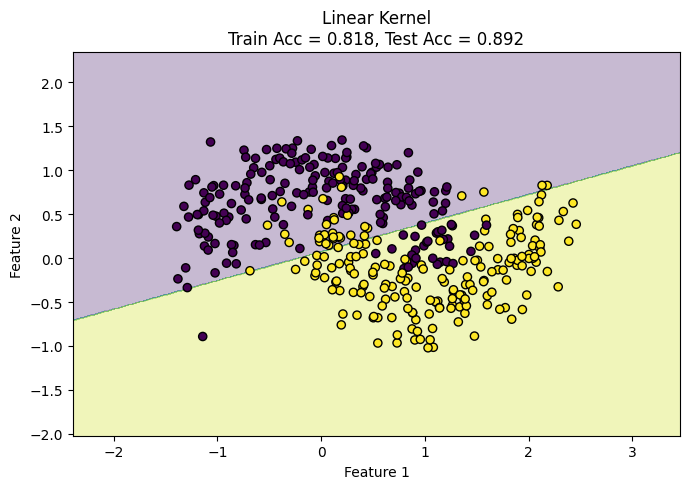

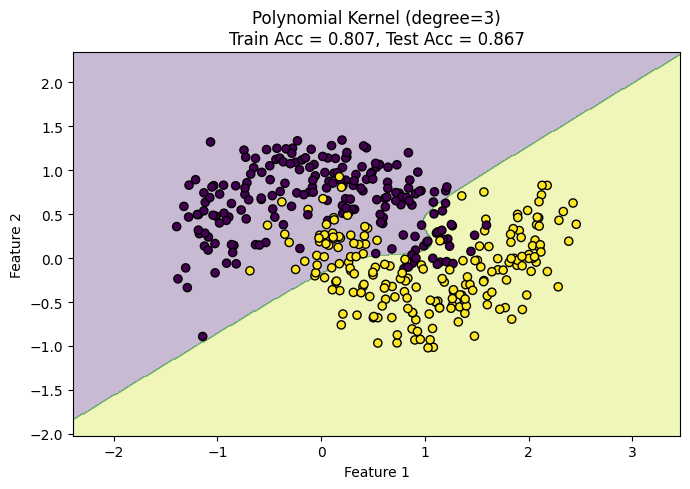

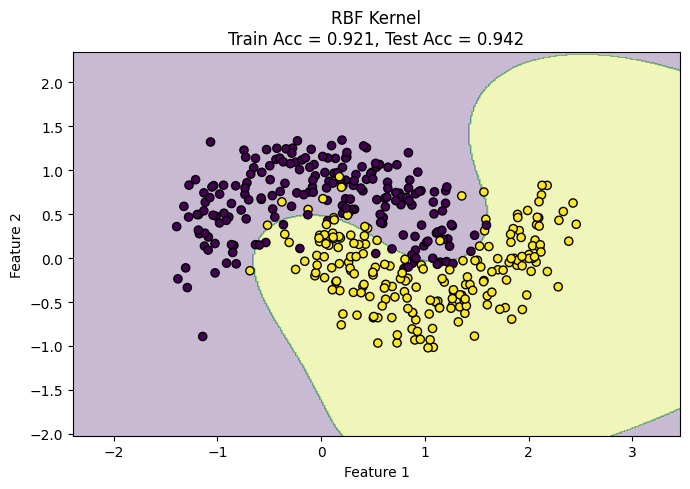

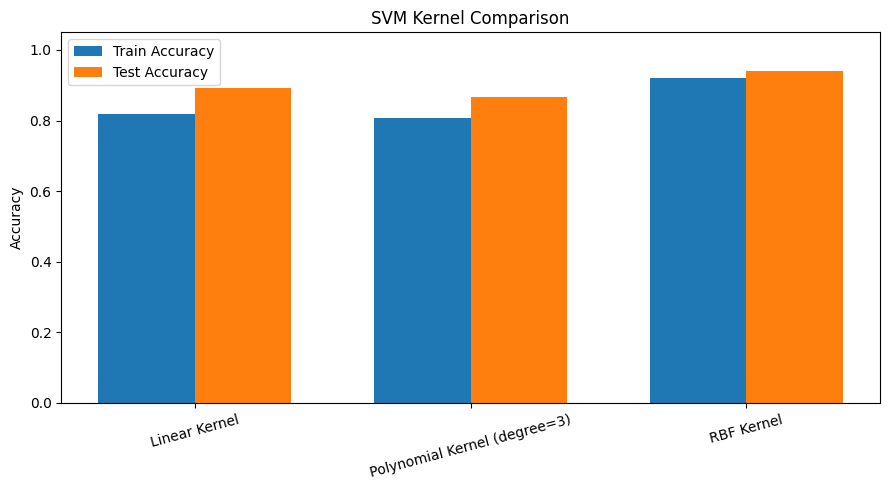

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# -------------------------------
# 1. Create dataset
# -------------------------------
X, y = make_moons(n_samples=400, noise=0.25, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

print("First 5 rows of features (X):")
print(X[:5])

print("\nFirst 5 rows of labels (y):")
print(y[:5])

# -------------------------------
# 2. Define SVM models
# -------------------------------
models = {
    "Linear Kernel": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear", C=1.0))
    ]),

    "Polynomial Kernel (degree=3)": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="poly", degree=3, C=1.0, gamma="scale"))
    ]),

    "RBF Kernel": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
    ])
}


# -------------------------------
# 3. Train and evaluate
# -------------------------------
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    results[name] = {
        "model": model,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "y_test_pred": y_test_pred
    }


# -------------------------------
# 4. Print results
# -------------------------------
print("\n=== Accuracy Results ===")
for name, info in results.items():
    print(f"{name}")
    print(f"  Train Accuracy: {info['train_acc']:.3f}")
    print(f"  Test Accuracy : {info['test_acc']:.3f}")
    print()

best_model_name = max(results, key=lambda k: results[k]["test_acc"])
best_model = results[best_model_name]["model"]

print("Best model based on test accuracy:", best_model_name)
print("\nClassification report for best model:\n")
print(classification_report(y_test, results[best_model_name]["y_test_pred"]))

print("Confusion matrix for best model:")
print(confusion_matrix(y_test, results[best_model_name]["y_test_pred"]))


# -------------------------------
# 5. Function to plot decision boundary
# -------------------------------
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", s=35)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.tight_layout()
    plt.show()


# -------------------------------
# 6. Plot decision boundaries
# -------------------------------
for name, info in results.items():
    title = (
        f"{name}\n"
        f"Train Acc = {info['train_acc']:.3f}, Test Acc = {info['test_acc']:.3f}"
    )
    plot_decision_boundary(info["model"], X, y, title)


# -------------------------------
# 7. Optional: compare all accuracies in one chart
# -------------------------------
model_names = list(results.keys())
train_scores = [results[name]["train_acc"] for name in model_names]
test_scores = [results[name]["test_acc"] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, train_scores, width, label="Train Accuracy")
plt.bar(x + width/2, test_scores, width, label="Test Accuracy")
plt.xticks(x, model_names, rotation=15)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("SVM Kernel Comparison")
plt.legend()
plt.tight_layout()
plt.show()